In [27]:
import tensorflow as tf
import keras_tuner as kt
import pandas as pd

In [28]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [29]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test/ 255.

In [30]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress",
"Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [31]:
class_names[y_train[0]]

'Ankle boot'

In [32]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_8, built=True>,
 <Dense name=dense_9, built=True>,
 <Dense name=dense_10, built=True>]

In [35]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [36]:
# history = model.fit(X_train, y_train, epochs=30,
#                     validation_data=(X_valid, y_valid))

In [37]:
# histroy save  
import pickle
# pickle.dump(history.history, open('history.pkl', 'wb'))
history = pickle.load(open('/media/prince/5A4E832F4E83034D/DL-foundation/models/img_history.pkl', 'rb'))

# model.save('model.h5')
model = tf.keras.models.load_model('/media/prince/5A4E832F4E83034D/DL-foundation/models/img_model.h5')

<Axes: >

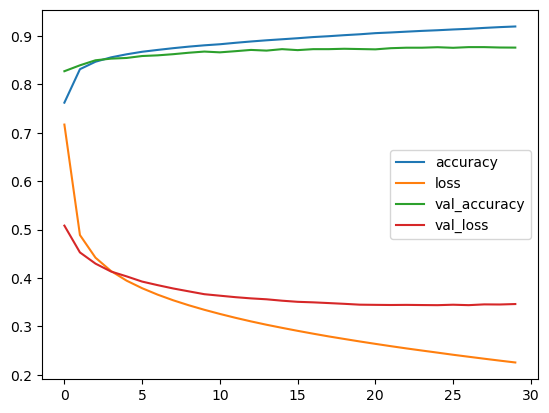

In [38]:
pd.DataFrame(history).plot()

In [39]:
X_new = X_test[:3]
y_proba = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


In [40]:
y_pred = y_proba.argmax(axis=-1)

In [41]:
import numpy as np
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [42]:
y_new_pred = y_test[:3]

In [43]:
y_new_pred

array([9, 2, 1], dtype=uint8)

In [44]:
def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=optimizer,
                  metrics=["accuracy"])
    return model

In [45]:
# random_search_tuner = kt.RandomSearch(
#     build_model, objective="val_accuracy", max_trials=5,
#     overwrite=True,
#     directory="my_fashion_mnist", project_name="my_rnd_search",
#     seed=42)
# random_search_tuner.search(X_train, y_train, epochs=10,
#     validation_data=(X_valid, y_valid))

In [46]:
# top3_models = random_search_tuner.get_best_models(num_models=3)
# best_model = top3_models[0]

In [47]:
# best_model.save("best_model.h5")
best_model = tf.keras.models.load_model('/media/prince/5A4E832F4E83034D/DL-foundation/models/img_best_model.h5')

In [48]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)
    
    def fit(self, hp, model, X, y, **kwargs):
        if hp.Boolean("normalize"):
            norm_layer = tf.keras.layers.Normalization()
            X = norm_layer(X)
        return model.fit(X, y, **kwargs)

In [49]:
hyperband_tuner = kt.Hyperband(
    MyClassificationHyperModel(),   # your custom HyperModel class
    objective="val_accuracy",       # what to optimize
    max_epochs=10,                 # max training for best model
    factor=3,                      # elimination rate (keep top 1/3)
    hyperband_iterations=2,        # repeat full process twice
    seed=42,                       # reproducibility
    overwrite=True,                # clear old runs
    directory="my_fashion_mnist",  # where results are saved
    project_name="hyperband"       # subfolder name
)

In [50]:
# early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)
# hyperband_tuner.search(
#     X_train, y_train, epochs=10,
#     validation_data=(X_valid, y_valid),
#     callbacks=[early_stopping_cb]
#     )